In [1]:
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

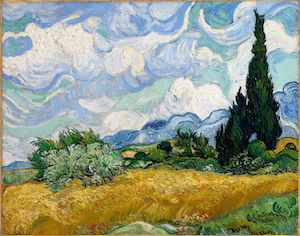

In [2]:
display(REFERENCE_IMAGE)

In [3]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True

In [ ]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./img/van_gogh_intermediate_{evo.seed}_{evo.population_size}_{evo.crossover_method}_{evo.num_points}_{evo.initialization}_{evo.generation_budget}_{time['num-generations']:05d}.png")

def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget = settings
    start = time()
    
    data = []
    evo = Evolution(num_points,
                    REFERENCE_IMAGE,
                    population_size=population_size,
                    generation_reporter=reporter,
                    crossover_method=crossover_method,
                    seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=.25,
                    selection_name='tournament_4',
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: run {seed} - pop {population_size} - crossover {crossover_method} - num. points {num_points} - initialization {initialization} - in {int(time_spent)} seconds")
    
    return data

## Running a single instance

In [5]:
%%time
data = run_algorithm((0, 100, "ONE_POINT", 100, 'RANDOM', 5000))
#seed, population_size, crossover_method, num_points, initialization, generation_budget

generation: 100 best fitness: 83172 avg. fitness: 83804.27
generation: 200 best fitness: 68932 avg. fitness: 69219.52
generation: 300 best fitness: 58834 avg. fitness: 58960.93
generation: 400 best fitness: 51533 avg. fitness: 51769.29
generation: 500 best fitness: 45635 avg. fitness: 45736.79
generation: 600 best fitness: 41672 avg. fitness: 41717.84
generation: 700 best fitness: 38914 avg. fitness: 38974.4
generation: 800 best fitness: 36782 avg. fitness: 36823.76
generation: 900 best fitness: 35000 avg. fitness: 35034.11
generation: 1000 best fitness: 34039 avg. fitness: 34069.5
generation: 1100 best fitness: 33105 avg. fitness: 33111.48
generation: 1200 best fitness: 32418 avg. fitness: 32439.86
generation: 1300 best fitness: 32004 avg. fitness: 32017.96
generation: 1400 best fitness: 31743 avg. fitness: 31747.86
generation: 1500 best fitness: 31536 avg. fitness: 31541.36
generation: 1600 best fitness: 31393 avg. fitness: 31398.43
generation: 1700 best fitness: 31320 avg. fitness: 

In [11]:
%%time
data = run_algorithm((0, 100, "ONE_POINT", 300, 'RANDOM', 500))
#seed, population_size, crossover_method, num_points, initialization, generation_budget

generation: 1 best fitness: 139476 avg. fitness: 147260.12
generation: 2 best fitness: 139476 avg. fitness: 144496.97
generation: 3 best fitness: 137170 avg. fitness: 142161.72
generation: 4 best fitness: 137170 avg. fitness: 140588.2
generation: 5 best fitness: 137121 avg. fitness: 139197.39
generation: 6 best fitness: 136705 avg. fitness: 138120.74
generation: 7 best fitness: 136533 avg. fitness: 137376.57
generation: 8 best fitness: 134556 avg. fitness: 136779.45
generation: 9 best fitness: 134556 avg. fitness: 136377.76
generation: 10 best fitness: 132588 avg. fitness: 135610.91
generation: 11 best fitness: 131849 avg. fitness: 134656.17
generation: 12 best fitness: 131283 avg. fitness: 133513.84
generation: 13 best fitness: 131283 avg. fitness: 132716.53
generation: 14 best fitness: 131283 avg. fitness: 132202.47
generation: 15 best fitness: 131070 avg. fitness: 131707.54
generation: 16 best fitness: 130329 avg. fitness: 131326.48
generation: 17 best fitness: 130329 avg. fitness: 

## Running a sweep of settings

In [ ]:
%%time

generation_budget = 500
 
data = []
for seed in range(3):
    for population_size in (100,):
        for crossover_method in ("ONE_POINT",):
            for initialization in ("RANDOM",):
                for num_points in (100,):
                    data.extend(run_algorithm((seed, population_size, crossover_method, num_points, initialization, generation_budget)))

## Evaluating the results

In [ ]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)

In [ ]:
# your plotting code here...

## Displaying the best instances over time

In [6]:
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, population_size, crossover_method, num_points, generation_budget = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(500, generation_budget + 500, 500)
    
    img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{population_size}_{crossover_method}_{num_points}_RANDOM_{generation_budget}_{i:05d}.png")) for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

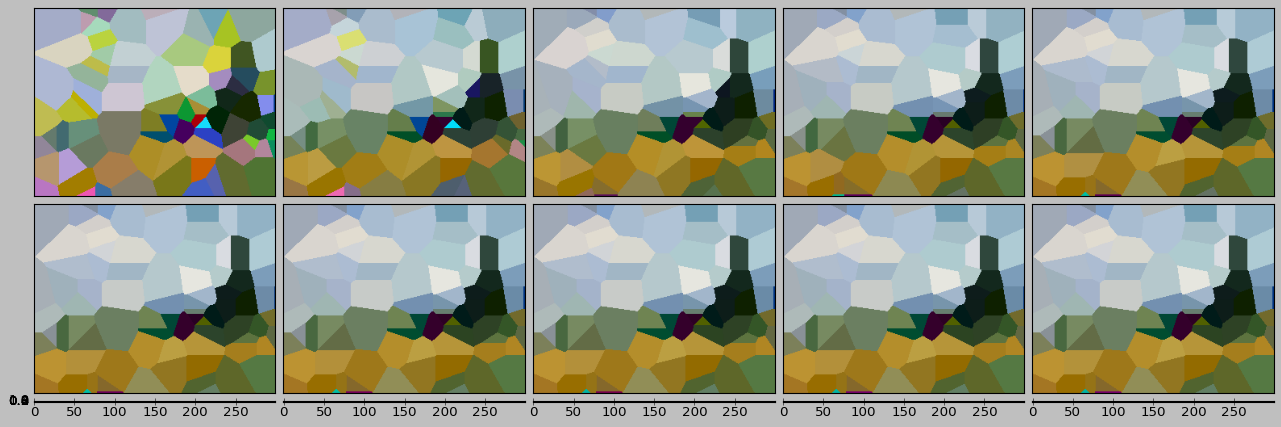

In [7]:
show_progress_over_time((0, 100, 'ONE_POINT', 100, 5000), grid=(3,5))

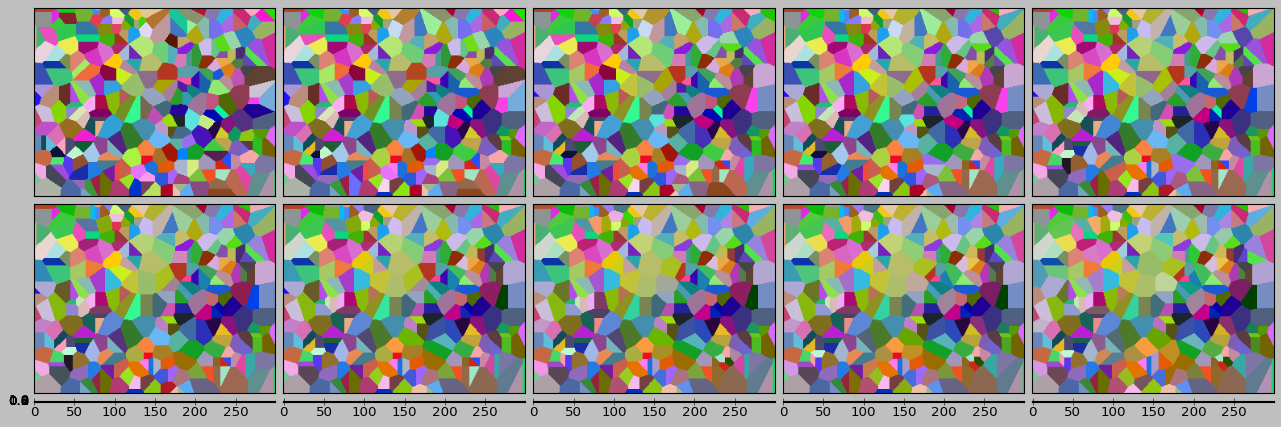

In [12]:
show_progress_over_time((0, 100, 'ONE_POINT', 300, 500), grid=(3,5))


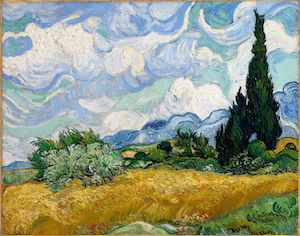

In [10]:
display(REFERENCE_IMAGE)